# Analyse exploratoire du dataset — Club Football Match Data (2000 → 2026)

**Objectif** : comprendre le dataset avant toute modélisation : taille, qualité, couverture, régularités du football, efficacité des cotes. La dernière partie teste de façon chiffrée des idées répandues (double chance, seuil de confiance, Over 1,5, combinés, Kelly).

**Cadre** : projet académique. Les cotes servent de référence d'information et d'objet d'étude, pas de support de pari.

Durée d'exécution : ~1 à 2 min sur Colab (CPU gratuit).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib as mpl, requests
from scipy.stats import poisson
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)

# Style des graphiques : palette catégorielle validée (bleu, orange, aqua), axes discrets
BLUE, ORANGE, AQUA, YELLOW, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
mpl.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.titlelocation": "left", "lines.linewidth": 2,
    "axes.prop_cycle": mpl.cycler(color=[BLUE, ORANGE, AQUA, YELLOW, VIOLET]), "legend.frameon": False,
    "figure.dpi": 110, "axes.axisbelow": True})
OUT = {"H": BLUE, "D": INK2, "A": ORANGE}          # couleur fixe par issue : domicile, nul, extérieur
BIG = {"E0": "Premier League", "SP1": "Liga", "I1": "Serie A", "D1": "Bundesliga", "F1": "Ligue 1"}

## 0. Vérifier la taille avant de télécharger (règle : pas de téléchargement au-delà de 3 Go)

In [2]:
URL = "https://raw.githubusercontent.com/xgabora/Club-Football-Match-Data-2000-2025/main/data/Matches.csv"
MAX_BYTES = 3 * 1024**3
size = int(requests.head(URL, allow_redirects=True, timeout=30, headers={"Accept-Encoding": "identity"}).headers.get("Content-Length", 0))
print(f"Taille annoncée : {size/1024**2:.1f} Mo")
assert 0 < size < MAX_BYTES, "Fichier trop gros (> 3 Go) ou taille inconnue : téléchargement annulé."
raw = pd.read_csv(URL, parse_dates=["MatchDate"], low_memory=False)
print(f"{raw.shape[0]:,} lignes × {raw.shape[1]} colonnes · mémoire {raw.memory_usage(deep=True).sum()/1024**2:.0f} Mo")

Taille annoncée : 43.3 Mo


238,858 lignes × 48 colonnes · mémoire 156 Mo


## 1. Aperçu général

In [3]:
df = raw.copy()
df["Season"] = np.where(df.MatchDate.dt.month >= 7, df.MatchDate.dt.year, df.MatchDate.dt.year - 1)
df["goals"] = df.FTHome + df.FTAway
print("Période :", df.MatchDate.min().date(), "→", df.MatchDate.max().date(), "|", df.Division.nunique(), "championnats |",
      pd.concat([df.HomeTeam, df.AwayTeam]).nunique(), "équipes")
display(df.head(3))
display(df.dtypes.value_counts().rename("nb colonnes").to_frame())

per_league = df.groupby("Division").agg(matchs=("FTResult", "size"), debut=("MatchDate", "min"), fin=("MatchDate", "max"),
                                        equipes=("HomeTeam", "nunique")).sort_values("matchs", ascending=False)
per_league["debut"], per_league["fin"] = per_league.debut.dt.date, per_league.fin.dt.date
display(per_league)

Période : 2000-07-28 → 2026-09-03 | 38 championnats | 1233 équipes


,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,Form5Away,FTHome,FTAway,FTResult,HTHome,HTAway,HTResult,HomeShots,AwayShots,HomeTarget,AwayTarget,HomeFouls,AwayFouls,HomeCorners,AwayCorners,HomeYellow,AwayYellow,HomeRed,AwayRed,OddHome,OddDraw,OddAway,MaxHome,MaxDraw,MaxAway,Over25,Under25,MaxOver25,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB,Season,goals
0,F1,2000-07-28,NaN,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,0.0,3.0,1.0,H,2.0,1.0,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.65,3.3,4.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000,4.0
1,F1,2000-07-28,NaN,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,0.0,3.0,1.0,H,1.0,1.0,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.60,3.4,4.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000,4.0
2,F2,2000-07-28,NaN,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,0.0,0.0,1.0,A,0.0,1.0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2000,1.0


,nb colonnes
float64,42
str,6
datetime64[us],1
int32,1


,matchs,debut,fin,equipes
Division,,,,
E1,14206,2000-08-12,2026-09-02,66
E2,13819,2000-08-12,2026-09-02,84
E3,13377,2001-04-16,2026-09-01,76
SP2,10992,2000-09-02,2026-08-31,87
I2,10321,2000-09-01,2026-08-30,79
E0,9810,2000-08-19,2026-08-31,47
SP1,9419,2000-09-09,2026-09-03,41
I1,9412,2000-09-30,2026-08-31,50
F1,9081,2000-07-28,2026-09-03,42


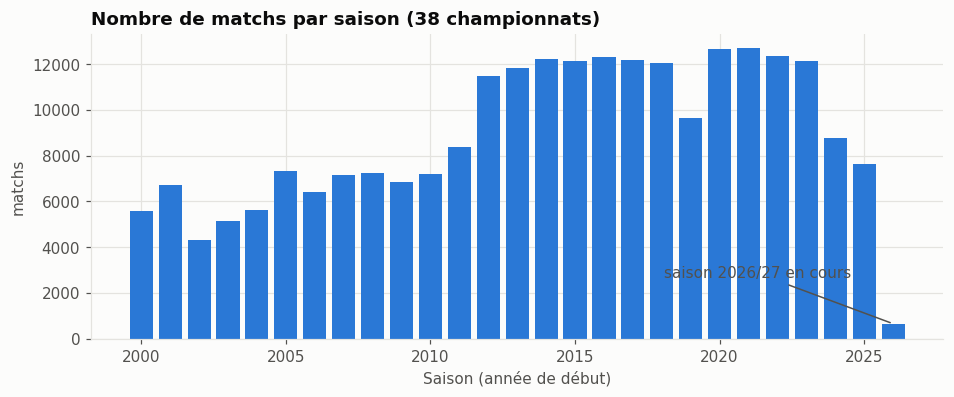

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.6))
cnt = df.groupby("Season").size()
ax.bar(cnt.index, cnt.values, color=BLUE, width=0.8)
ax.set_title("Nombre de matchs par saison (38 championnats)"); ax.set_xlabel("Saison (année de début)"); ax.set_ylabel("matchs")
ax.annotate("saison 2026/27 en cours", (cnt.index[-1], cnt.values[-1]), xytext=(-150, 30), textcoords="offset points",
            color=INK2, arrowprops=dict(arrowstyle="-", color=INK2))
plt.show()

## 2. Qualité des données
### 2.1 Valeurs manquantes par groupe de colonnes et par période

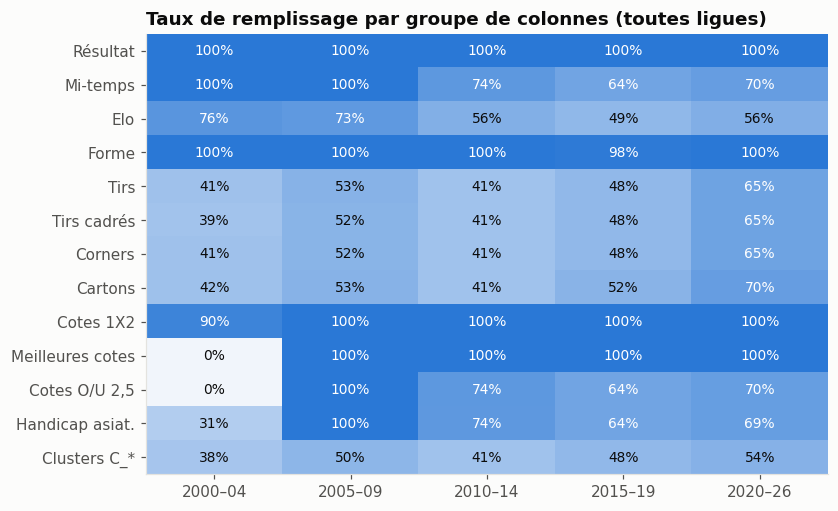

Elo à ~50–75 % seulement : ClubElo ne couvre pas les ligues hors Europe ni certaines divisions inférieures.
Lecture : les statistiques de match et les cotes Over/Under ne sont fiables qu'à partir de ~2005–2006 ; les clusters C_* sont vides pour les derniers matchs et, surtout, calculés à partir du match lui-même (fuite).


In [5]:
groups = {"Résultat": ["FTHome", "FTAway", "FTResult"], "Mi-temps": ["HTHome", "HTAway"], "Elo": ["HomeElo", "AwayElo"],
          "Forme": ["Form5Home", "Form5Away"], "Tirs": ["HomeShots", "AwayShots"], "Tirs cadrés": ["HomeTarget", "AwayTarget"],
          "Corners": ["HomeCorners", "AwayCorners"], "Cartons": ["HomeYellow", "AwayYellow"], "Cotes 1X2": ["OddHome", "OddDraw", "OddAway"],
          "Meilleures cotes": ["MaxHome", "MaxDraw", "MaxAway"], "Cotes O/U 2,5": ["Over25", "Under25"], "Handicap asiat.": ["HandiSize"],
          "Clusters C_*": ["C_LTH"]}
df["era"] = pd.cut(df.Season, [1999, 2004, 2009, 2014, 2019, 2030], labels=["2000–04", "2005–09", "2010–14", "2015–19", "2020–26"])
cov = pd.DataFrame({g: df[c].notna().all(axis=1).groupby(df.era, observed=True).mean() for g, c in groups.items()}).T
fig, ax = plt.subplots(figsize=(8, 5.2))
im = ax.imshow(cov.values, cmap=mpl.colors.LinearSegmentedColormap.from_list("b", ["#f1f5fb", BLUE]), vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(cov.shape[1]), cov.columns); ax.set_yticks(range(cov.shape[0]), cov.index); ax.grid(False)
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        v = cov.values[i, j]; ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=9, color="white" if v > .6 else INK)
ax.set_title("Taux de remplissage par groupe de colonnes (toutes ligues)"); plt.show()
print("Elo à ~50–75 % seulement : ClubElo ne couvre pas les ligues hors Europe ni certaines divisions inférieures.")
print("Lecture : les statistiques de match et les cotes Over/Under ne sont fiables qu'à partir de ~2005–2006 ;"
      " les clusters C_* sont vides pour les derniers matchs et, surtout, calculés à partir du match lui-même (fuite).")

In [6]:
by_league = pd.DataFrame({g: df[df.Season >= 2015][c].notna().all(axis=1).groupby(df.Division).mean() for g, c in list(groups.items())[3:9]})
display(by_league.sort_values("Tirs").style.format("{:.0%}").background_gradient(cmap="Blues", vmin=0, vmax=1))
print("Les ligues hors Europe (ARG, BRA, USA, JAP, CHN…) n'ont ni tirs ni corners : pour les modèles à statistiques, se limiter aux ligues européennes.")

,Forme,Tirs,Tirs cadrés,Corners,Cartons,Cotes 1X2
Division,,,,,,
ARG,100%,0%,0%,0%,0%,100%
AUT,100%,0%,0%,0%,0%,100%
BRA,75%,0%,0%,0%,0%,100%
CHN,100%,0%,0%,0%,0%,100%
DEN,100%,0%,0%,0%,0%,100%
FIN,100%,0%,0%,0%,0%,100%
NOR,100%,0%,0%,0%,0%,100%
IRL,100%,0%,0%,0%,0%,100%
JAP,100%,0%,0%,0%,0%,100%


Les ligues hors Europe (ARG, BRA, USA, JAP, CHN…) n'ont ni tirs ni corners : pour les modèles à statistiques, se limiter aux ligues européennes.


### 2.2 Doublons, incohérences et valeurs extrêmes

In [7]:
key = ["Division", "MatchDate", "HomeTeam", "AwayTeam"]
checks = {
    "doublons (ligue, date, équipes)": df.duplicated(key).sum(),
    "résultat manquant": df.FTResult.isna().sum(),
    "FTResult incohérent avec le score": ((df.FTHome > df.FTAway) & (df.FTResult != "H") | (df.FTHome < df.FTAway) & (df.FTResult != "A")
                                         | (df.FTHome == df.FTAway) & (df.FTResult != "D")).sum(),
    "buts mi-temps > buts fin de match": ((df.HTHome > df.FTHome) | (df.HTAway > df.FTAway)).sum(),
    "tirs cadrés > tirs": ((df.HomeTarget > df.HomeShots) | (df.AwayTarget > df.AwayShots)).sum(),
    "buts > tirs cadrés": ((df.FTHome > df.HomeTarget) | (df.FTAway > df.AwayTarget)).sum(),
    "cote < 1,01": (df[["OddHome", "OddDraw", "OddAway"]] < 1.01).any(axis=1).sum(),
    "somme des 1/cote < 1 (marge négative)": ((1/df.OddHome + 1/df.OddDraw + 1/df.OddAway) < 1).sum(),
    "match à 10 buts ou plus": (df.goals >= 10).sum(),
}
display(pd.Series(checks, name="nombre de lignes").to_frame())
print("« buts > tirs cadrés » vient surtout des buts contre son camp (non comptés comme tirs) : ce n'est pas une erreur.")

,nombre de lignes
"doublons (ligue, date, équipes)",0
résultat manquant,4
FTResult incohérent avec le score,0
buts mi-temps > buts fin de match,0
tirs cadrés > tirs,17
buts > tirs cadrés,802
"cote < 1,01",7
somme des 1/cote < 1 (marge négative),3
match à 10 buts ou plus,103


« buts > tirs cadrés » vient surtout des buts contre son camp (non comptés comme tirs) : ce n'est pas une erreur.


## 3. Ce que disent les résultats (5 grands championnats, 2005/06 → 2025/26)

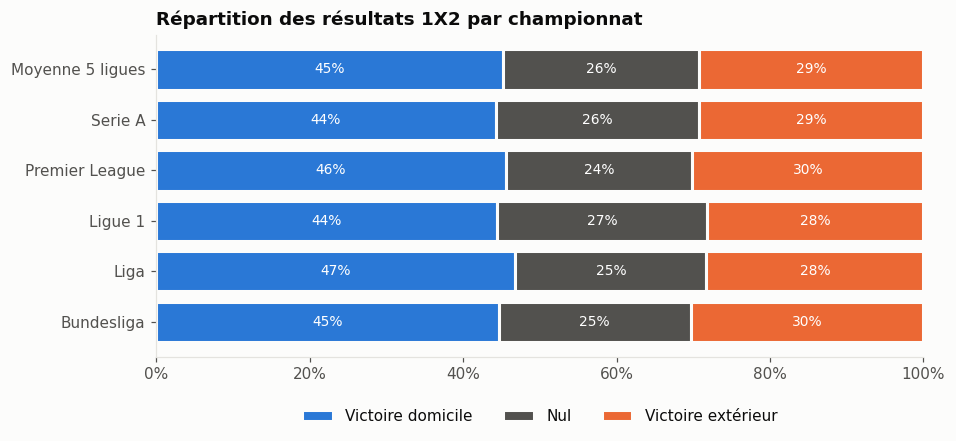

In [8]:
B = df[df.Division.isin(BIG) & df.Season.between(2005, 2025)].copy()
B["Ligue"] = B.Division.map(BIG)
rates = pd.crosstab(B.Ligue, B.FTResult, normalize="index")[["H", "D", "A"]]
rates.loc["Moyenne 5 ligues"] = B.FTResult.value_counts(normalize=True)[["H", "D", "A"]]
fig, ax = plt.subplots(figsize=(9, 3.8))
left = np.zeros(len(rates))
for k, lab in [("H", "Victoire domicile"), ("D", "Nul"), ("A", "Victoire extérieur")]:
    ax.barh(rates.index, rates[k], left=left, color=OUT[k], label=lab, edgecolor="#fcfcfb", linewidth=2)
    for i, v in enumerate(rates[k]): ax.text(left[i] + v/2, i, f"{v:.0%}", ha="center", va="center", color="white", fontsize=9)
    left += rates[k].values
ax.set_xlim(0, 1); ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); ax.grid(False)
ax.set_title("Répartition des résultats 1X2 par championnat"); ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(.5, -.12)); plt.show()

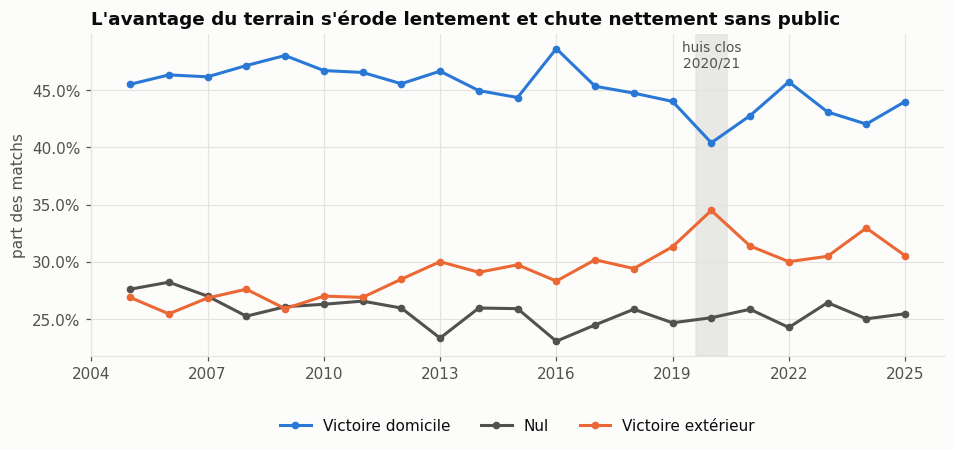

In [9]:
season = B.groupby("Season").agg(dom=("FTResult", lambda s: (s == "H").mean()), nul=("FTResult", lambda s: (s == "D").mean()),
                                 ext=("FTResult", lambda s: (s == "A").mean()))
fig, ax = plt.subplots(figsize=(10, 3.8))
for c, k, lab in [("dom", "H", "Victoire domicile"), ("nul", "D", "Nul"), ("ext", "A", "Victoire extérieur")]:
    ax.plot(season.index, season[c], marker="o", ms=4, color=OUT[k], label=lab)
ax.axvspan(2019.6, 2020.4, color=GRID, alpha=.8); ax.text(2020, .47, "huis clos\n2020/21", ha="center", color=INK2, fontsize=9)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); ax.set_ylabel("part des matchs")
ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
ax.set_title("L'avantage du terrain s'érode lentement et chute nettement sans public")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(.5, -.15)); plt.show()

### 3.1 Les buts suivent-ils une loi de Poisson ?

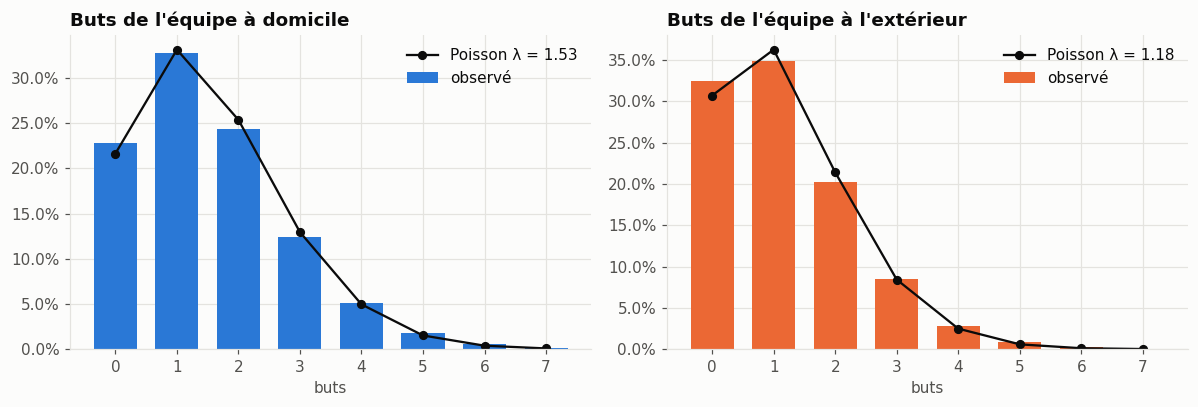

,,observé,Poisson indépendant
0.000000,0.000000,7.5%,6.6%
1.000000,0.000000,10.0%,10.2%
0.000000,1.000000,7.1%,7.8%
1.000000,1.000000,11.9%,12.0%
2.000000,2.000000,5.1%,5.4%


Le 0-0 est plus fréquent que prévu (7,5 % vs 6,6 %) et le 0-1 moins fréquent : les petits scores s'écartent du Poisson indépendant, d'où la correction de Dixon-Coles.


In [10]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, col, lab, c in [(axs[0], "FTHome", "Buts de l'équipe à domicile", BLUE), (axs[1], "FTAway", "Buts de l'équipe à l'extérieur", ORANGE)]:
    obs = B[col].value_counts(normalize=True).sort_index().reindex(range(8), fill_value=0)
    lam = B[col].mean()
    ax.bar(obs.index, obs.values, color=c, width=.7, label="observé")
    ax.plot(obs.index, poisson.pmf(obs.index, lam), "o-", color=INK, lw=1.5, ms=5, label=f"Poisson λ = {lam:.2f}")
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); ax.set_title(lab); ax.set_xlabel("buts"); ax.legend()
plt.tight_layout(); plt.show()
dd = B.groupby(["FTHome", "FTAway"]).size() / len(B)
indep = {(i, j): poisson.pmf(i, B.FTHome.mean()) * poisson.pmf(j, B.FTAway.mean()) for i, j in dd.index}
low = pd.DataFrame({"observé": dd, "Poisson indépendant": pd.Series(indep)}).loc[[(0, 0), (1, 0), (0, 1), (1, 1), (2, 2)]]
display(low.style.format("{:.1%}"))
print("Le 0-0 est plus fréquent que prévu (7,5 % vs 6,6 %) et le 0-1 moins fréquent : les petits scores s'écartent du Poisson indépendant, d'où la correction de Dixon-Coles.")

In [11]:
lines = [0.5, 1.5, 2.5, 3.5, 4.5]
over = pd.DataFrame({l: B.groupby("Ligue").goals.apply(lambda g: (g > l).mean()) for l in lines})
over.columns = [f"Over {l}" for l in lines]
display(over.style.format("{:.0%}"))
print(f"BTTS (les deux équipes marquent) : {((B.FTHome > 0) & (B.FTAway > 0)).mean():.0%}  ·  "
      f"Top 5 des scores : {', '.join(f'{h:.0f}-{a:.0f} ({p:.1%})' for (h, a), p in dd.sort_values(ascending=False).head(5).items())}")

,Over 0.5,Over 1.5,Over 2.5,Over 3.5,Over 4.5
Ligue,,,,,
Bundesliga,94%,81%,57%,35%,18%
Liga,93%,74%,50%,27%,14%
Ligue 1,91%,72%,47%,26%,11%
Premier League,93%,76%,52%,30%,14%
Serie A,92%,75%,50%,28%,13%


BTTS (les deux équipes marquent) : 52%  ·  Top 5 des scores : 1-1 (11.9%), 1-0 (10.0%), 2-1 (8.8%), 2-0 (7.8%), 0-0 (7.5%)


## 4. Force des équipes : Elo et forme

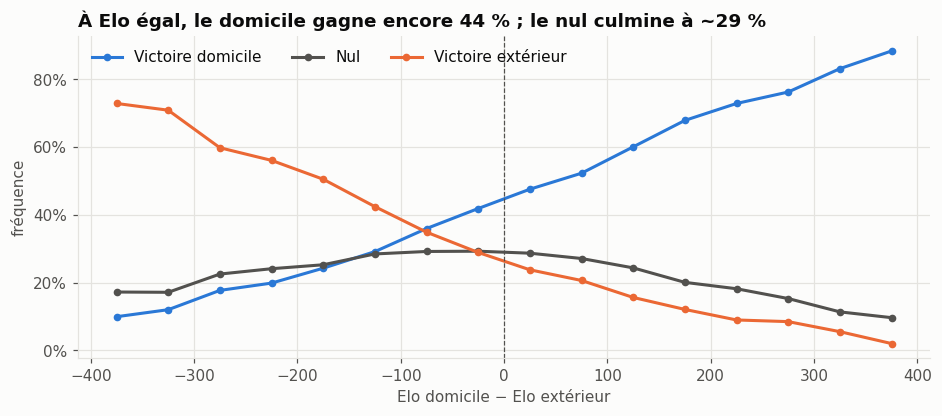

Avantage du terrain à Elo égal (|écart| < 25) : domicile 44.4%, nul 29.2%, extérieur 26.4%


In [12]:
B["elo_diff"] = B.HomeElo - B.AwayElo
bins = pd.cut(B.elo_diff, np.arange(-400, 401, 50))
g = B.groupby(bins, observed=True).FTResult.value_counts(normalize=True).unstack()[["H", "D", "A"]]
x = [iv.mid for iv in g.index]
fig, ax = plt.subplots(figsize=(10, 3.8))
for k, lab in [("H", "Victoire domicile"), ("D", "Nul"), ("A", "Victoire extérieur")]:
    ax.plot(x, g[k], marker="o", ms=4, color=OUT[k], label=lab)
ax.axvline(0, color=INK2, lw=.8, ls="--")
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); ax.set_xlabel("Elo domicile − Elo extérieur"); ax.set_ylabel("fréquence")
ax.set_title("À Elo égal, le domicile gagne encore 44 % ; le nul culmine à ~29 %")
ax.legend(ncol=3, loc="upper left"); plt.show()
eq = B[B.elo_diff.abs() < 25].FTResult.value_counts(normalize=True)
print(f"Avantage du terrain à Elo égal (|écart| < 25) : domicile {eq['H']:.1%}, nul {eq['D']:.1%}, extérieur {eq['A']:.1%}")

In [13]:
B["form_diff"] = B.Form5Home - B.Form5Away
fb = B.groupby(pd.cut(B.form_diff, [-16, -8, -4, -1, 1, 4, 8, 16]), observed=True).agg(
    matchs=("FTResult", "size"), dom=("FTResult", lambda s: (s == "H").mean()), elo=("elo_diff", "mean"))
display(fb.style.format({"dom": "{:.1%}", "elo": "{:+.0f}"}))
print("La forme récente est très corrélée à l'Elo : une grande partie de son effet est déjà dans la force de l'équipe.")

,matchs,dom,elo
form_diff,,,
"(-16, -8]",2377,25.7%,-185
"(-8, -4]",6935,34.2%,-93
"(-4, -1]",8717,41.0%,-32
"(-1, 1]",6311,46.3%,+15
"(1, 4]",7230,51.7%,+56
"(4, 8]",4929,59.9%,+127
"(8, 16]",1143,72.1%,+209


La forme récente est très corrélée à l'Elo : une grande partie de son effet est déjà dans la force de l'équipe.


## 5. Statistiques de match (ce qu'on ne connaît qu'après le coup)

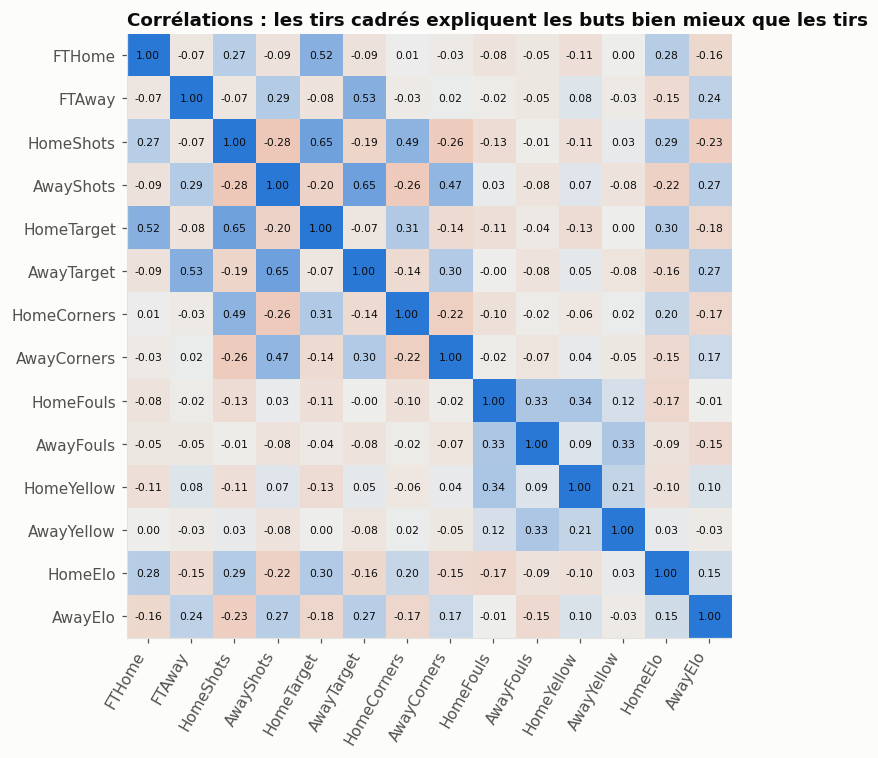

Conversion moyenne : 29.3% des tirs cadrés deviennent des buts.


In [14]:
S = B.dropna(subset=["HomeShots", "HomeTarget", "HomeCorners"])
num = S[["FTHome", "FTAway", "HomeShots", "AwayShots", "HomeTarget", "AwayTarget", "HomeCorners", "AwayCorners",
         "HomeFouls", "AwayFouls", "HomeYellow", "AwayYellow", "HomeElo", "AwayElo"]]
C = num.corr()
fig, ax = plt.subplots(figsize=(8.5, 7))
cmap = mpl.colors.LinearSegmentedColormap.from_list("div", [ORANGE, "#eeeeec", BLUE])
ax.imshow(C.values, cmap=cmap, vmin=-1, vmax=1); ax.grid(False)
ax.set_xticks(range(len(C)), C.columns, rotation=60, ha="right"); ax.set_yticks(range(len(C)), C.columns)
for i in range(len(C)):
    for j in range(len(C)): ax.text(j, i, f"{C.values[i, j]:.2f}", ha="center", va="center", fontsize=7, color=INK)
ax.set_title("Corrélations : les tirs cadrés expliquent les buts bien mieux que les tirs"); plt.tight_layout(); plt.show()
conv = (S.FTHome.sum() + S.FTAway.sum()) / (S.HomeTarget.sum() + S.AwayTarget.sum())
print(f"Conversion moyenne : {conv:.1%} des tirs cadrés deviennent des buts.")

In [15]:
r = B.dropna(subset=["HomeRed", "AwayRed"])
red = pd.DataFrame({
    "aucun rouge": r[(r.HomeRed == 0) & (r.AwayRed == 0)].FTResult.value_counts(normalize=True),
    "rouge pour le domicile": r[(r.HomeRed > 0) & (r.AwayRed == 0)].FTResult.value_counts(normalize=True),
    "rouge pour l'extérieur": r[(r.HomeRed == 0) & (r.AwayRed > 0)].FTResult.value_counts(normalize=True)}).T[["H", "D", "A"]]
red["part des matchs"] = [((r.HomeRed == 0) & (r.AwayRed == 0)).mean(), ((r.HomeRed > 0) & (r.AwayRed == 0)).mean(), ((r.HomeRed == 0) & (r.AwayRed > 0)).mean()]
display(red.style.format("{:.1%}"))
print("Un carton rouge divise par deux les chances de victoire, mais il arrive PENDANT le match : c'est du bruit pour un modèle d'avant-match.")

FTResult,H,D,A,part des matchs
aucun rouge,45.2%,25.7%,29.1%,81.0%
rouge pour le domicile,23.2%,27.1%,49.8%,7.3%
rouge pour l'extérieur,62.0%,23.7%,14.4%,9.9%


Un carton rouge divise par deux les chances de victoire, mais il arrive PENDANT le match : c'est du bruit pour un modèle d'avant-match.


## 5 bis. Tous les « marchés » statistiques : cartons, corners, tirs cadrés, buts…
Pour chaque statistique : moyenne par match (total, domicile, extérieur), distribution, fréquence de dépassement des lignes usuelles (« plus de X,5 ») et **cote juste** correspondante (= 1 / fréquence, sans marge).
Le dataset ne contient pas les cotes réelles des marchés cartons/corners/tirs : ces cotes justes servent de référence probabiliste, pas de prix de marché.

In [16]:
MARKETS = {  # nom : (colonne domicile, colonne extérieur, lignes usuelles)
    "Buts":               ("FTHome", "FTAway", [0.5, 1.5, 2.5, 3.5, 4.5]),
    "Buts 1re mi-temps":  ("HTHome", "HTAway", [0.5, 1.5, 2.5]),
    "Tirs cadrés":        ("HomeTarget", "AwayTarget", [6.5, 7.5, 8.5, 9.5, 10.5]),
    "Tirs":               ("HomeShots", "AwayShots", [20.5, 22.5, 24.5, 26.5, 28.5]),
    "Corners":            ("HomeCorners", "AwayCorners", [7.5, 8.5, 9.5, 10.5, 11.5]),
    "Cartons jaunes":     ("HomeYellow", "AwayYellow", [2.5, 3.5, 4.5, 5.5, 6.5]),
    "Cartons rouges":     ("HomeRed", "AwayRed", [0.5, 1.5]),
    "Fautes":             ("HomeFouls", "AwayFouls", [20.5, 22.5, 24.5, 26.5]),
}
MK = B.dropna(subset=[c for h, a, _ in MARKETS.values() for c in (h, a)]).copy()
for name, (h, a, _) in MARKETS.items():
    MK[name] = MK[h] + MK[a]
print(f"{len(MK):,} matchs des 5 grands championnats avec toutes les statistiques ({MK.Season.min()}/{MK.Season.min()+1-2000:02d} → {MK.Season.max()}/{MK.Season.max()+1-2000:02d})")

# Moyennes de l'ensemble
avg = pd.DataFrame({name: {"moyenne par match": MK[name].mean(), "domicile": MK[h].mean(), "extérieur": MK[a].mean(),
                           "médiane": MK[name].median(), "écart-type": MK[name].std(), "min": MK[name].min(), "max": MK[name].max()}
                    for name, (h, a, _) in MARKETS.items()}).T
display(avg.style.format("{:.2f}").format("{:.0f}", subset=["médiane", "min", "max"]))

36,556 matchs des 5 grands championnats avec toutes les statistiques (2005/06 → 2025/26)


,moyenne par match,domicile,extérieur,médiane,écart-type,min,max
Buts,2.72,1.54,1.19,3,1.67,0,12
Buts 1re mi-temps,1.20,0.68,0.52,1,1.09,0,8
Tirs cadrés,9.29,5.16,4.13,9,3.57,0,33
Tirs,24.94,13.79,11.15,25,5.89,3,54
Corners,10.08,5.62,4.46,10,3.48,0,28
Cartons jaunes,4.03,1.87,2.15,4,2.12,0,15
Cartons rouges,0.22,0.10,0.12,0,0.50,0,5
Fautes,27.34,13.47,13.86,27,7.73,0,72


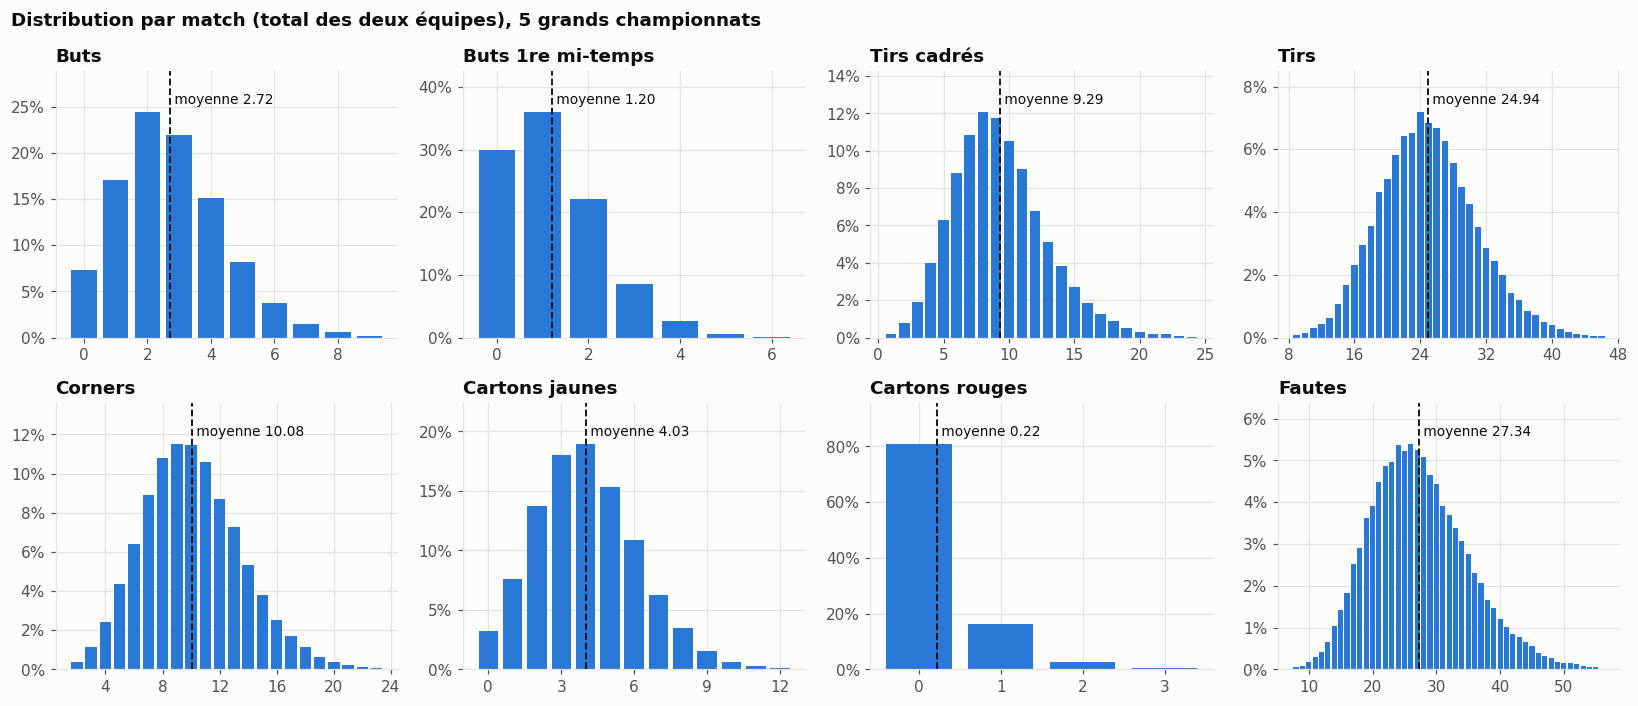

In [17]:
# Distributions : une petite figure par statistique, moyenne en pointillés
fig, axs = plt.subplots(2, 4, figsize=(15, 6.5))
for ax, name in zip(axs.ravel(), MARKETS):
    v = MK[name]; lo, hi = int(v.quantile(.001)), int(v.quantile(.999))
    freq = v.value_counts(normalize=True).sort_index().reindex(range(lo, hi + 1), fill_value=0)
    ax.bar(freq.index, freq.values, color=BLUE, width=0.8)
    ax.axvline(v.mean(), color=INK, ls="--", lw=1.2)
    ax.text(v.mean(), freq.max() * 1.02, f" moyenne {v.mean():.2f}", color=INK, fontsize=9, va="bottom")
    ax.set_title(name); ax.set_ylim(0, freq.max() * 1.18)
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1, decimals=0))
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True, nbins=6))
fig.suptitle("Distribution par match (total des deux équipes), 5 grands championnats", x=.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

In [18]:
# Fréquence des lignes « plus de X,5 » et cote juste équivalente
rows = []
for name, (h, a, lines) in MARKETS.items():
    for l in lines:
        p = (MK[name] > l).mean()
        rows.append({"marché": name, "ligne": f"plus de {l:g}", "fréquence": p, "cote juste « plus »": 1 / p if p > 0 else np.nan,
                     "cote juste « moins »": 1 / (1 - p) if p < 1 else np.nan})
lines_tab = pd.DataFrame(rows).set_index(["marché", "ligne"])
display(lines_tab.style.format({"fréquence": "{:.1%}", "cote juste « plus »": "{:.2f}", "cote juste « moins »": "{:.2f}"}))

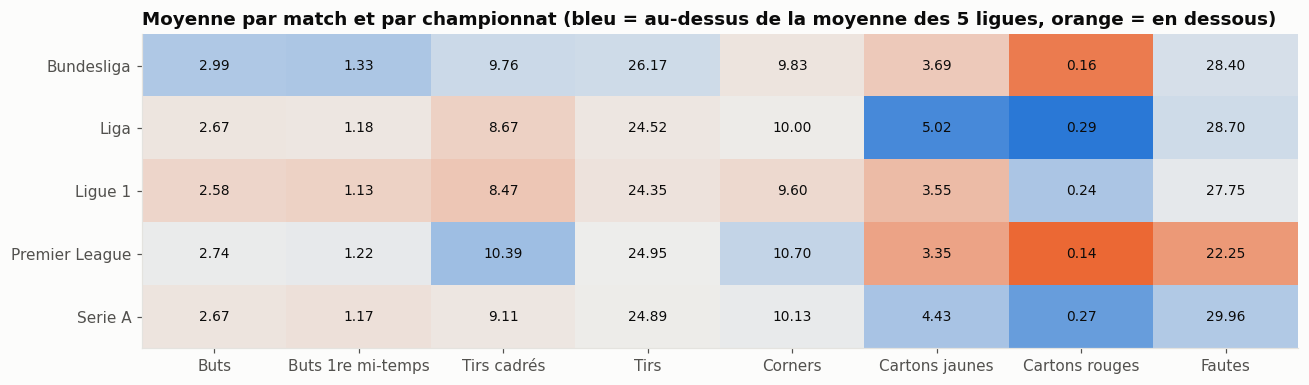

La Bundesliga a le plus de buts ; la Liga et la Serie A le plus de cartons ; la Premier League le plus de tirs cadrés et de corners mais le moins de fautes. Un modèle de marchés statistiques doit donc intégrer la ligue.


In [19]:
# Moyennes par championnat (heatmap normalisée par colonne : couleur = écart à la moyenne des 5 ligues)
by_lg = MK.groupby("Ligue")[list(MARKETS)].mean()
rel = by_lg / by_lg.mean() - 1
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.imshow(rel.values, cmap=mpl.colors.LinearSegmentedColormap.from_list("div", [ORANGE, "#eeeeec", BLUE]), vmin=-.3, vmax=.3, aspect="auto")
ax.grid(False); ax.set_xticks(range(rel.shape[1]), rel.columns); ax.set_yticks(range(rel.shape[0]), rel.index)
for i in range(rel.shape[0]):
    for j in range(rel.shape[1]):
        ax.text(j, i, f"{by_lg.values[i, j]:.2f}", ha="center", va="center", fontsize=9, color=INK)
ax.set_title("Moyenne par match et par championnat (bleu = au-dessus de la moyenne des 5 ligues, orange = en dessous)")
plt.tight_layout(); plt.show()
print("La Bundesliga a le plus de buts ; la Liga et la Serie A le plus de cartons ; la Premier League le plus de tirs cadrés et de corners mais le moins de fautes."
      " Un modèle de marchés statistiques doit donc intégrer la ligue.")

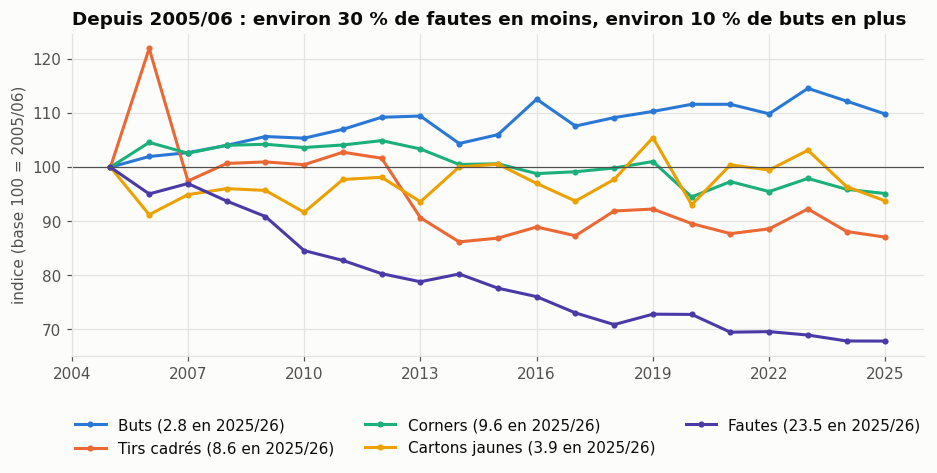

Le pic des tirs cadrés en 2006/07 ressemble à un changement de méthode de comptage de la source : à garder en tête avant d'utiliser cette variable sur des saisons anciennes.


In [20]:
# Évolution des moyennes dans le temps (indice base 100 = première saison disponible)
trend = MK.groupby("Season")[["Buts", "Tirs cadrés", "Corners", "Cartons jaunes", "Fautes"]].mean()
idx = trend / trend.iloc[0] * 100
fig, ax = plt.subplots(figsize=(10, 3.8))
for (col, c) in zip(idx.columns, [BLUE, ORANGE, AQUA, YELLOW, VIOLET]):
    ax.plot(idx.index, idx[col], marker="o", ms=3, color=c, label=f"{col} ({trend[col].iloc[-1]:.1f} en {trend.index[-1]}/{trend.index[-1]+1-2000:02d})")
ax.axhline(100, color=INK2, lw=.8); ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
ax.set_ylabel(f"indice (base 100 = {trend.index[0]}/{trend.index[0]+1-2000:02d})")
ax.set_title("Depuis 2005/06 : environ 30 % de fautes en moins, environ 10 % de buts en plus")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(.5, -.15)); plt.show()
print("Le pic des tirs cadrés en 2006/07 ressemble à un changement de méthode de comptage de la source : à garder en tête avant d'utiliser cette variable sur des saisons anciennes.")

## 6. Le marché des cotes

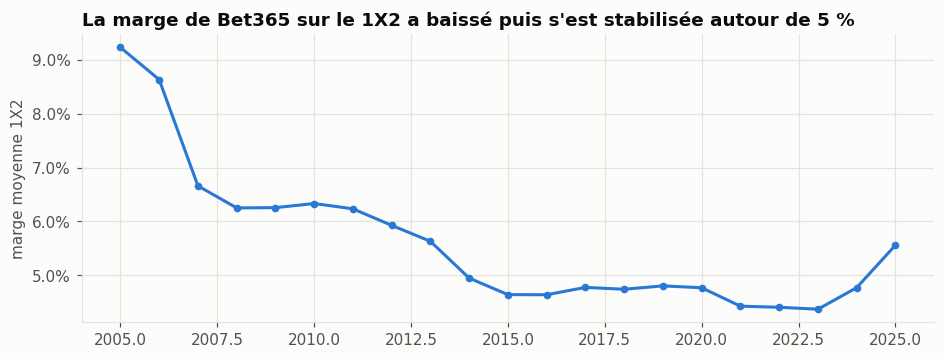

In [21]:
M = B.dropna(subset=["OddHome", "OddDraw", "OddAway"]).copy()
inv = 1 / M[["OddHome", "OddDraw", "OddAway"]].values
M["margin"] = inv.sum(1) - 1
P = inv / inv.sum(1, keepdims=True)
M[["pH", "pD", "pA"]] = P
M["y"] = M.FTResult.map({"H": 0, "D": 1, "A": 2})
M["fav"] = P.argmax(1); M["pfav"] = P.max(1); M["fav_win"] = M.fav == M.y
mm = M.groupby("Season").margin.mean()
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(mm.index, mm.values, marker="o", ms=4, color=BLUE)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1, decimals=1)); ax.set_ylabel("marge moyenne 1X2")
ax.set_title("La marge de Bet365 sur le 1X2 a baissé puis s'est stabilisée autour de 5 %"); plt.show()

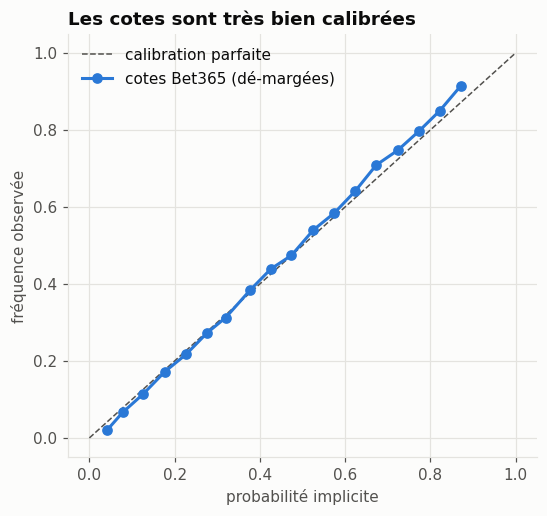

Le favori des cotes gagne 53.3% des matchs ; le nul n'est favori que dans 0.16% des cas.


In [22]:
cal = pd.DataFrame({"p": np.r_[M.pH, M.pD, M.pA], "o": np.r_[M.y == 0, M.y == 1, M.y == 2]})
cb = cal.groupby(pd.cut(cal.p, np.arange(0, 1.01, .05)), observed=True).agg(p=("p", "mean"), o=("o", "mean"), n=("o", "size"))
cb = cb[cb.n > 100]
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], color=INK2, lw=1, ls="--", label="calibration parfaite")
ax.plot(cb.p, cb.o, "o-", color=BLUE, label="cotes Bet365 (dé-margées)")
ax.set_xlabel("probabilité implicite"); ax.set_ylabel("fréquence observée"); ax.legend(loc="upper left")
ax.set_title("Les cotes sont très bien calibrées"); plt.show()
print(f"Le favori des cotes gagne {M.fav_win.mean():.1%} des matchs ; le nul n'est favori que dans {(M.fav == 1).mean():.2%} des cas.")

## 7. Tester les idées répandues sur la « réduction du risque »
Chaque affirmation est traduite en question mesurable, puis vérifiée sur les données (5 grands championnats, 2005/06 → 2025/26).

### 7.1 « La double chance (1X ou X2) passe plus de 80–85 % du temps »

In [23]:
M["fav_not_lose"] = np.where(M.fav == 0, M.y != 2, M.y != 0)
dc = M[M.fav != 1].groupby(pd.cut(M.pfav, [0, .4, .5, .6, .7, .8, 1]), observed=True).agg(
    matchs=("y", "size"), favori_gagne=("fav_win", "mean"), favori_ne_perd_pas=("fav_not_lose", "mean"))
# cote juste et cote bookmaker d'une double chance : 1 / (p1 + pX)
M["dc_prob"] = np.where(M.fav == 0, M.pH + M.pD, M.pA + M.pD)
M["dc_bookodds"] = 1 / np.where(M.fav == 0, inv[:, 0] + inv[:, 1], inv[:, 2] + inv[:, 1])
M["dc_return"] = np.where(M.fav_not_lose, M.dc_bookodds - 1, -1)
dc["rendement moyen par unité"] = M[M.fav != 1].groupby(pd.cut(M.pfav, [0, .4, .5, .6, .7, .8, 1]), observed=True).dc_return.mean()
display(dc.style.format({"favori_gagne": "{:.1%}", "favori_ne_perd_pas": "{:.1%}", "rendement moyen par unité": "{:+.1%}"}))
print("Vrai : la double chance du favori passe souvent (> 85 % quand le favori est net). Mais la cote baisse d'autant :"
      " le rendement reste négatif dans chaque tranche. Une probabilité élevée ne réduit pas la perte attendue, elle réduit la variance.")

,matchs,favori_gagne,favori_ne_perd_pas,rendement moyen par unité
pfav,,,,
"(0.0, 0.4]",7016,38.7%,69.5%,-2.3%
"(0.4, 0.5]",12940,45.5%,74.2%,-4.1%
"(0.5, 0.6]",8319,56.0%,81.6%,-4.1%
"(0.6, 0.7]",5226,67.4%,87.6%,-4.0%
"(0.7, 0.8]",2982,76.9%,92.0%,-4.2%
"(0.8, 1.0]",1090,87.2%,96.2%,-3.5%


Vrai : la double chance du favori passe souvent (> 85 % quand le favori est net). Mais la cote baisse d'autant : le rendement reste négatif dans chaque tranche. Une probabilité élevée ne réduit pas la perte attendue, elle réduit la variance.


### 7.2 « N'émettre un signal que si la probabilité dépasse 75 % » (option de rejet)
En apprentissage automatique, c'est la **prédiction sélective** : on échange la couverture (part des matchs prédits) contre la précision.

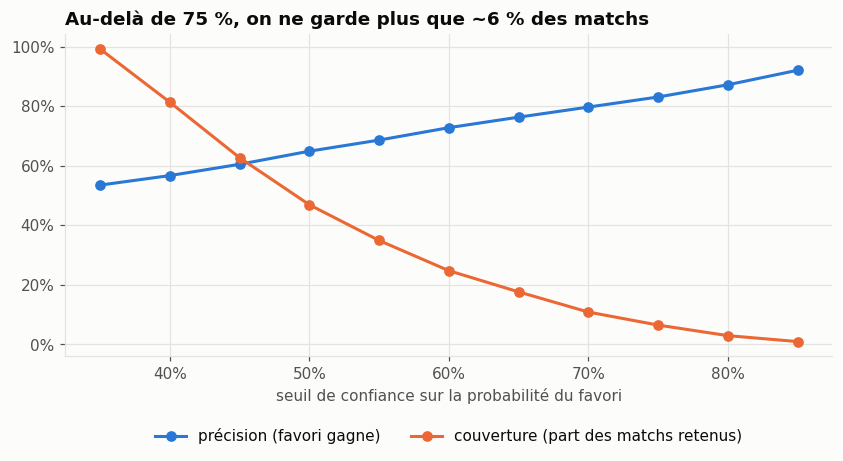

,seuil,couverture,précision,proba moyenne annoncée
0,35%,99.2%,53.5%,52.1%
1,40%,81.3%,56.7%,55.2%
2,45%,62.7%,60.5%,59.0%
3,50%,46.9%,64.8%,62.9%
4,55%,34.9%,68.6%,66.4%
5,60%,24.7%,72.7%,70.1%
6,65%,17.6%,76.3%,73.3%
7,70%,10.8%,79.7%,77.0%
8,75%,6.4%,83.1%,80.3%
9,80%,2.9%,87.2%,83.8%


La précision au-dessus du seuil ≈ la probabilité annoncée : le filtre ne crée pas d'information, il choisit les matchs faciles.


In [24]:
thr = np.arange(.35, .90, .05)
sel = pd.DataFrame({"seuil": thr, "couverture": [(M.pfav >= t).mean() for t in thr],
                    "précision": [M.fav_win[M.pfav >= t].mean() for t in thr],
                    "proba moyenne annoncée": [M.pfav[M.pfav >= t].mean() for t in thr]})
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(sel.seuil, sel["précision"], marker="o", color=BLUE, label="précision (favori gagne)")
ax.plot(sel.seuil, sel.couverture, marker="o", color=ORANGE, label="couverture (part des matchs retenus)")
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1))
ax.set_xlabel("seuil de confiance sur la probabilité du favori"); ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(.5, -.18))
ax.set_title("Au-delà de 75 %, on ne garde plus que ~6 % des matchs"); plt.show()
display(sel.style.format({"seuil": "{:.0%}", "couverture": "{:.1%}", "précision": "{:.1%}", "proba moyenne annoncée": "{:.1%}"}))
print("La précision au-dessus du seuil ≈ la probabilité annoncée : le filtre ne crée pas d'information, il choisit les matchs faciles.")

### 7.3 « Plus de 1,5 but arrive dans 75–80 % des matchs »

In [25]:
o15 = B.groupby("Ligue").goals.apply(lambda g: (g > 1.5).mean())
o15.loc["Moyenne 5 ligues"] = (B.goals > 1.5).mean()
display(o15.rename("Over 1,5").to_frame().style.format("{:.1%}"))
print("Vrai en moyenne ; c'est justement pour cela que la cote correspondante est basse (le dataset n'a pas de cote Over 1,5 pour mesurer la marge).")

,"Over 1,5"
Ligue,
Bundesliga,80.6%
Liga,74.0%
Ligue 1,72.4%
Premier League,76.0%
Serie A,75.0%
Moyenne 5 ligues,75.4%


Vrai en moyenne ; c'est justement pour cela que la cote correspondante est basse (le dataset n'a pas de cote Over 1,5 pour mesurer la marge).


### 7.4 Les combinés : la probabilité se multiplie, la marge aussi

In [26]:
fav75 = M[(M.pfav >= .75) & (M.fav != 1)].copy()
fav75["week"] = fav75.MatchDate.dt.to_period("W")
rng = np.random.default_rng(0); rows = []
for k in [1, 2, 3, 4, 5]:
    wins, probs, rets = [], [], []
    for _, wk in fav75.groupby("week"):
        if len(wk) < k: continue
        for _ in range(20):
            s = wk.sample(k, random_state=int(rng.integers(1e9)))
            win = s.fav_win.all(); odds = np.prod(1 / np.where(s.fav == 0, 1 / s.OddHome, 1 / s.OddAway))
            wins.append(win); probs.append(np.prod(s.pfav)); rets.append(odds - 1 if win else -1)
    rows.append({"matchs combinés": k, "probabilité attendue (produit)": np.mean(probs), "taux de réussite observé": np.mean(wins),
                 "rendement moyen par unité": np.mean(rets), "tickets simulés": len(wins)})
comb = pd.DataFrame(rows).set_index("matchs combinés")
display(comb.style.format({"probabilité attendue (produit)": "{:.1%}", "taux de réussite observé": "{:.1%}", "rendement moyen par unité": "{:+.1%}"}))
print(f"Marge moyenne sur ces favoris : {M.loc[fav75.index, 'margin'].mean():.1%}. Sur k matchs, le retour attendu ≈ (1 − marge)^k − 1 :"
      " la perte attendue grossit avec chaque sélection ajoutée.")

,probabilité attendue (produit),taux de réussite observé,rendement moyen par unité,tickets simulés
matchs combinés,,,,
1,80.1%,83.5%,-1.1%,14680
2,64.3%,68.0%,-4.7%,12000
3,52.0%,58.2%,-4.2%,8820
4,41.9%,49.9%,-2.6%,5660
5,33.6%,40.6%,-5.8%,3540


Marge moyenne sur ces favoris : 5.2%. Sur k matchs, le retour attendu ≈ (1 − marge)^k − 1 : la perte attendue grossit avec chaque sélection ajoutée.


### 7.5 Kelly : « risque de faillite statistiquement nul » ?
Kelly suppose que la probabilité p est **exacte**. On simule 1 000 paris à cote 2,10 avec une vraie probabilité de 0,50 (avantage +5 %), quand le modèle croit 0,50 (juste) ou 0,55 (trop optimiste de 5 points).

In [27]:
def kelly_sim(p_true, p_model, odds=2.10, n=1000, frac=1.0, sims=3000, seed=1):
    r = np.random.default_rng(seed)
    f = max(0.0, frac * (p_model * odds - 1) / (odds - 1))
    wins = r.random((sims, n)) < p_true
    growth = np.where(wins, 1 + f * (odds - 1), 1 - f)
    path = np.cumprod(growth, axis=1)
    dd = 1 - path / np.maximum.accumulate(path, axis=1)
    return {"mise (% bankroll)": f, "bankroll médiane finale": np.median(path[:, -1]),
            "P(perte à la fin)": (path[:, -1] < 1).mean(), "P(chute de 50 % en cours de route)": (dd.max(1) >= .5).mean()}
ks = pd.DataFrame({
    "Kelly complet, p juste": kelly_sim(.50, .50),
    "Kelly complet, p surestimé": kelly_sim(.50, .55),
    "1/4 de Kelly, p surestimé": kelly_sim(.50, .55, frac=.25),
    "Sans avantage réel (p = 0,476), 1/4 Kelly": kelly_sim(.476, .55, frac=.25)}).T
display(ks.style.format({"mise (% bankroll)": "{:.1%}", "bankroll médiane finale": "{:.2f}", "P(perte à la fin)": "{:.1%}", "P(chute de 50 % en cours de route)": "{:.1%}"}))
print("Kelly ne rend jamais le risque nul : même avec p exact, une chute de moitié en cours de route est fréquente ;"
      " avec p surestimé, Kelly complet mise trop et détruit la bankroll. Sans avantage réel, aucune formule de mise ne gagne.")

,mise (% bankroll),bankroll médiane finale,P(perte à la fin),P(chute de 50 % en cours de route)
"Kelly complet, p juste",4.5%,3.11,22.8%,97.2%
"Kelly complet, p surestimé",14.1%,0.02,78.8%,100.0%
"1/4 de Kelly, p surestimé",3.5%,2.94,17.6%,82.8%
"Sans avantage réel (p = 0,476), 1/4 Kelly",3.5%,0.50,71.8%,97.8%


Kelly ne rend jamais le risque nul : même avec p exact, une chute de moitié en cours de route est fréquente ; avec p surestimé, Kelly complet mise trop et détruit la bankroll. Sans avantage réel, aucune formule de mise ne gagne.


### 7.6 « Pénaliser plus fort les erreurs sur les favoris » (coût asymétrique)
Une perte asymétrique pousse le modèle à **déformer** ses probabilités : il devient mal calibré. Pour produire des probabilités fiables, il faut garder une règle de score propre (log loss) ; l'asymétrie se gère ensuite, au moment de la décision, par un seuil. C'est la séparation classique « estimation / décision ».

## 8. Synthèse pour la modélisation
1. **Taille** : ~45 Mo, 239 000 matchs, 38 ligues ; rien à craindre côté mémoire sur Colab.
2. **Période utile** : à partir de 2005/06 pour les statistiques et les cotes ; ligues européennes seulement pour tirs et corners.
3. **À exclure** : clusters `C_*` (fuite), toute statistique du match à prédire (tirs, cartons…).
4. **Régularités à modéliser** : avantage du terrain (variable dans le temps, effondré en 2020/21), nuls sur-représentés vs Poisson, poids dominant de la force relative (Elo).
5. **Référence** : les cotes sont bien calibrées ; le favori ne gagne qu'environ 54 % du temps. Une précision de 50–54 % en 1X2 est donc normale ; la métrique principale doit être la log loss.
6. **Idées répandues** : double chance, seuil élevé et Over 1,5 augmentent la probabilité de réussite mais pas la valeur ; les combinés multiplient la marge ; Kelly suppose un p exact.